# Explaining a k-NN Classifier with LIME on Mixed-Type Tabular Data

This notebook trains a `KNeighborsClassifier` on the Titanic dataset, which mixes
**numeric** features (`Age`, `Fare`) with **categorical** ones (`Sex`, `Embarked`, `Pclass`).
Unlike the plain [LIME.ipynb](LIME.ipynb) example (all-numeric Breast Cancer data), this
notebook focuses on the extra preprocessing step LIME needs when categorical features
are involved.

**Workflow:**
1. Load and clean the raw Titanic data.
2. Label-encode categorical features so the whole feature matrix is numeric.
3. Fit a preprocessing pipeline (scaling + one-hot encoding) and train the k-NN model.
4. Build a `LimeTabularExplainer` that samples perturbations in the *raw* (label-encoded)
   feature space, and wrap the model's `predict_proba` so it accepts that raw space too.
5. Explain a single test instance and visualize the result.

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from matplotlib import pyplot as plt
import lime
import lime.lime_tabular

import warnings
warnings.filterwarnings('ignore')

SEED = 2025

## 1. Load & Clean the Data

Drop identifier/free-text columns that aren't useful as model features (`Name`, `Ticket`,
`Cabin`), and impute the small number of missing `Age`/`Embarked` values.

In [35]:
df = pd.read_csv("titanic_dataset.csv")

# Dropping useless columns
df = df.drop(columns=['Name', 'Ticket', 'Cabin'])

# Handling missing data
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

## 2. Encode Categorical Features

LIME's tabular explainer needs a single numeric feature matrix, with categorical columns
represented as label-encoded integers (it perturbs/report those categories itself via its
`categorical_features` argument, configured in [Section 4](#4.-Build-the-LIME-Explainer)).

`categorical_names` keeps the original string classes for each encoded categorical feature,
so LIME can display human-readable category names in its explanations instead of raw
integer codes.

In [36]:
numeric_features = ['Age', 'Fare']
categorical_features = ['Sex', 'Embarked', 'Pclass']
num_feats_idx = [0, 1]
cat_feats_idx = [2, 3, 4]
all_features = numeric_features + categorical_features

X = df[all_features].values
y = df['Survived']

In [37]:
categorical_names = {}
for fname, f_idx in zip(categorical_features, cat_feats_idx):
    le = LabelEncoder()
    le.fit(X[:, f_idx])
    X[:, f_idx] = le.transform(X[:, f_idx])
    categorical_names[fname] = le.classes_

# `df[all_features].values` mixes numeric (float) and categorical (originally string)
# columns, so numpy stores X as dtype=object even after label-encoding. Cast to a plain
# numeric dtype now so downstream transformers (OneHotEncoder, StandardScaler) fit on
# proper float arrays instead of object arrays, which is what caused the
# `ufunc 'isnan' not supported` error when preprocessing a single raw query row.
X = X.astype(float)

In [38]:
categorical_names

{'Sex': array(['female', 'male'], dtype=object),
 'Embarked': array(['C', 'Q', 'S'], dtype=object),
 'Pclass': array([1, 2, 3], dtype=object)}

## 3. Preprocess & Train the Model

Split the data, then fit a `StandardScaler` on the numeric features and a `OneHotEncoder`
on the (label-encoded) categorical features. `preprocess` applies both and is reused for
every downstream call, whether on the full training batch or a single raw query row (as
needed by LIME's `predict_fn`).

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=SEED)

scaler = StandardScaler().fit(X_train[:, num_feats_idx])
ohe = OneHotEncoder(sparse_output=False).fit(X_train[:, cat_feats_idx])


def preprocess(q: np.ndarray) -> np.ndarray:
    """Scale numeric features and one-hot encode categorical features.

    Accepts either a single raw sample (1D) or a batch of raw samples (2D), both using
    the same label-encoded feature layout as `X_train`/`X_test`.

    Args:
        q: Raw feature array, shape (n_features,) or (n_samples, n_features).

    Returns:
        Preprocessed array of shape (n_samples, n_scaled_features + n_encoded_features).
    """
    if q.ndim == 1:
        q = np.expand_dims(q, 0)
    q = q.astype(float)
    q_scaled = scaler.transform(q[:, num_feats_idx])
    q_encoded = ohe.transform(q[:, cat_feats_idx])
    return np.hstack((q_scaled, q_encoded))

In [40]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(preprocess(X_train), y_train)

test_accuracy = knn.score(preprocess(X_test), y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.7649


## 4. Build the LIME Explainer

The explainer is fit directly on the raw (label-encoded, not scaled/one-hot-encoded)
training data. Passing `categorical_features`/`categorical_names` tells LIME which columns
to treat as categorical when it perturbs an instance, and how to render their values.

In [41]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    class_names=['Not survived', 'Survived'],
    feature_names=all_features,
    categorical_features=cat_feats_idx,
    categorical_names=categorical_names,
)

## 5. Bridge LIME's Raw Space to the Model's Preprocessed Space

LIME calls `predict_fn` with raw, label-encoded rows (the same space `X_train` is in), but
`knn` expects scaled/one-hot-encoded input. `predict_fn` closes that gap by running
`preprocess` before calling `knn.predict_proba`.

In [42]:
predict_fn = lambda x: knn.predict_proba(preprocess(x))

# Sanity check on a single raw row before handing predict_fn to the explainer.
predict_fn(X_test[0])

array([[1., 0.]])

## 6. Explain a Single Test Instance

Ask LIME to explain the k-NN's prediction for one test row, then visualize the result.

In [43]:
instance_idx = 0

exp = explainer.explain_instance(
    data_row=X_test[instance_idx],
    predict_fn=predict_fn,
    num_features=len(all_features),
    top_labels=1,
)

# `top_labels=1` only computes the explanation for the model's top predicted class for
# this instance, which may be 0 ("Not survived") or 1 ("Survived") depending on the row —
# so read the available label back from the explanation instead of assuming it's 1.
top_label = exp.available_labels()[0]
exp.as_list(label=top_label)

[('Sex=1', 0.4578499030705541),
 ('Pclass=2', 0.20797152614710665),
 ('Age <= 22.00', -0.09363851847420826),
 ('14.50 < Fare <= 31.00', 0.056792205111629725),
 ('Embarked=0', -0.0023203439637554195)]

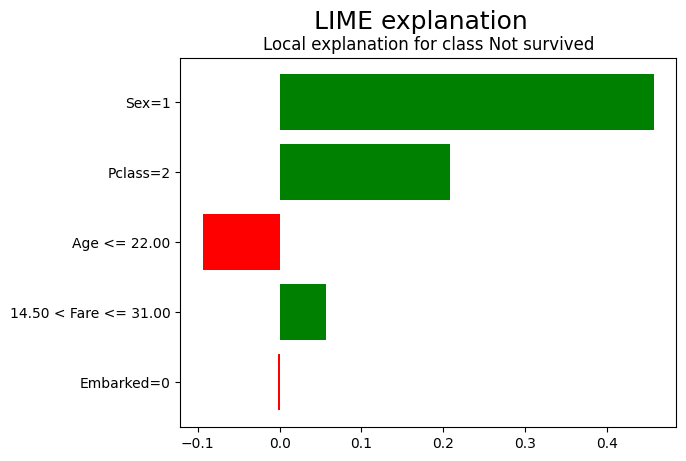

In [44]:
fig = exp.as_pyplot_figure(label=top_label)
fig.suptitle('LIME explanation', fontsize=18)
plt.show()